In [2]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

sns.set_theme(style="ticks")
folder_path = r'D:\clone\merged'

In [3]:
def get_climate_data(filename):
    path = os.path.join(folder_path, filename)
    ds = xr.open_dataset(path)
    if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: ds = ds.mean(dim='expver')
    ds = ds.sortby('time')
    
    var_name = list(ds.data_vars)[0]
    data = ds[var_name]
    
    if 'temperature' in filename: data = data - 273.15
    
    ts_monthly = data.mean(dim=['latitude', 'longitude']).resample(time='1MS').mean().compute().to_dataframe(name=var_name)
    spatial_climatology = data.mean(dim='time').compute()
    
    yearly = data.resample(time='1YS').mean()
    spatial_trend = (yearly[-5:].mean(dim='time') - yearly[:5].mean(dim='time')).compute()
    
    raw_data_copy = data.compute()
    ds.close()
    gc.collect()
    
    return ts_monthly, spatial_climatology, spatial_trend, raw_data_copy, var_name

In [4]:
df_t2m, map_t2m, trend_t2m, raw_t2m, name_t2m = get_climate_data('2m_temperature_merged.nc')
df_t2m.head()

,number,t2m
time,,
1980-01-01,0,22.453865
1980-02-01,0,22.867079
1980-03-01,0,25.951124
1980-04-01,0,26.856434
1980-05-01,0,27.323635


In [5]:
df_tp, map_tp, trend_tp, raw_tp, name_tp = get_climate_data('mean_total_precipitation_rate_merged.nc')
df_tp.head()

,number,avg_tprate
time,,
1980-01-01,0,0.000010
1980-02-01,0,0.000013
1980-03-01,0,0.000015
1980-04-01,0,0.000028
1980-05-01,0,0.000073


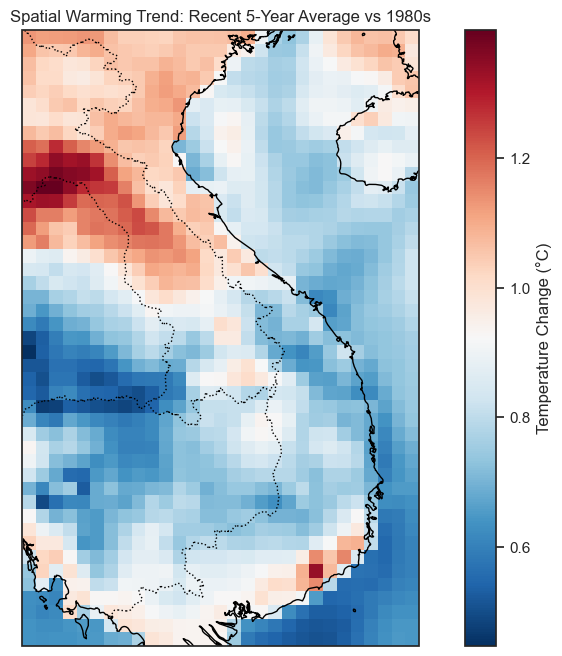

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')

trend_t2m.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', cbar_kwargs={'label': 'Temperature Change (°C)'})
plt.title("Spatial Warming Trend: Recent 5-Year Average vs 1980s")
plt.show()

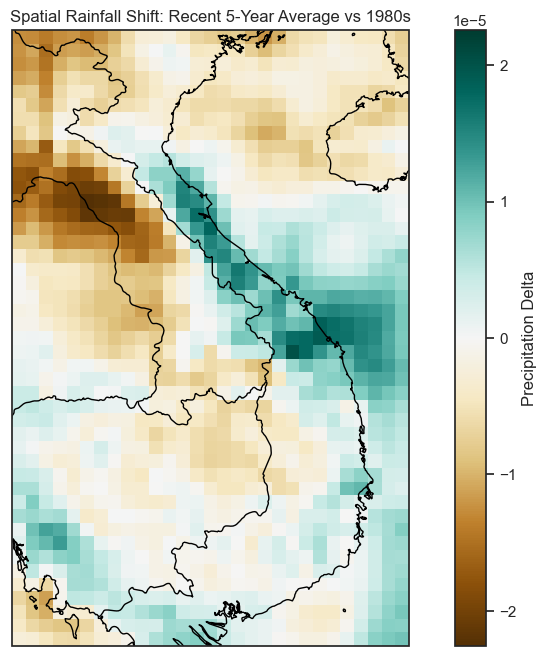

In [7]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

trend_tp.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='BrBG', cbar_kwargs={'label': 'Precipitation Delta'})
plt.title("Spatial Rainfall Shift: Recent 5-Year Average vs 1980s")
plt.show()

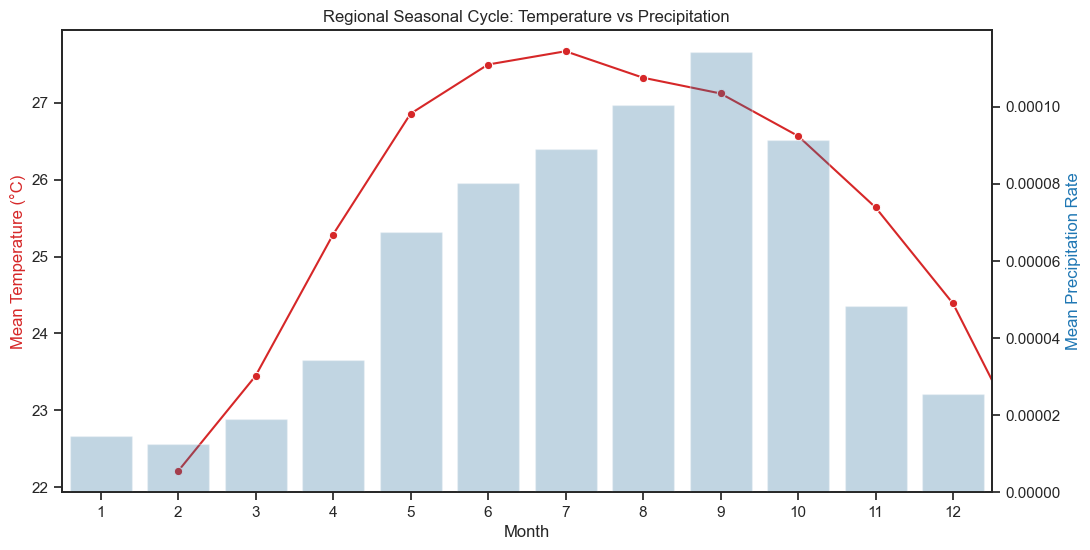

In [8]:
df_final = pd.concat([df_t2m, df_tp], axis=1).dropna()
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year
df_final['Decade'] = (df_final['Year'] // 10) * 10

seasonal = df_final.groupby('Month').mean()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(data=seasonal, x=seasonal.index, y=name_t2m, ax=ax1, color='tab:red', marker='o')
sns.barplot(data=seasonal, x=seasonal.index, y=name_tp, ax=ax2, color='tab:blue', alpha=0.3)

ax1.set_xlabel('Month')
ax1.set_ylabel('Mean Temperature (°C)', color='tab:red')
ax2.set_ylabel('Mean Precipitation Rate', color='tab:blue')
plt.title("Regional Seasonal Cycle: Temperature vs Precipitation")
plt.show()

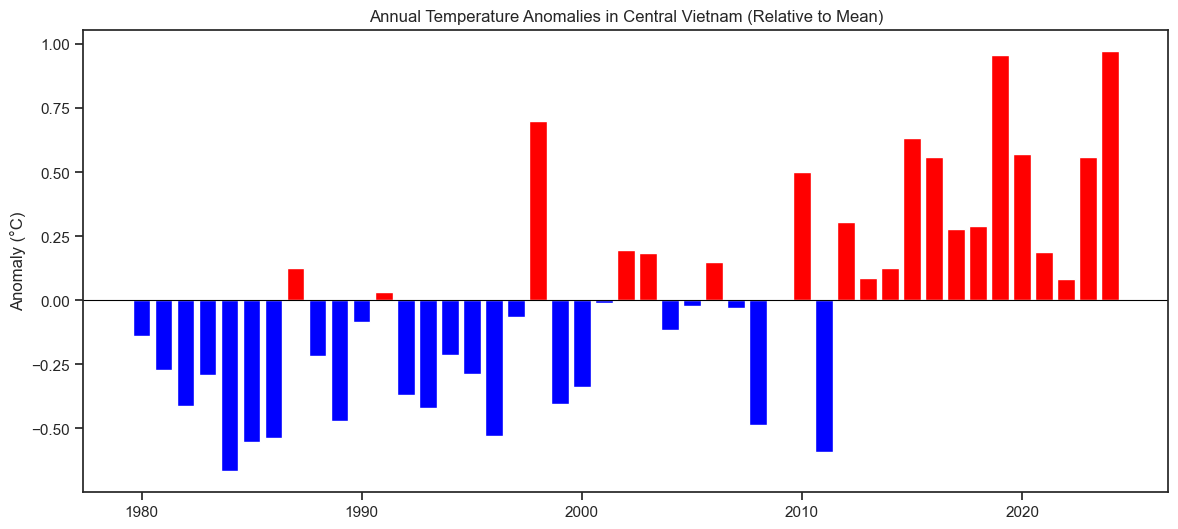

In [9]:
plt.figure(figsize=(14, 6))
df_yearly = df_final.resample('1YS').mean()
df_yearly['t2m_anomaly'] = df_yearly[name_t2m] - df_yearly[name_t2m].mean()

colors = ['red' if x > 0 else 'blue' for x in df_yearly['t2m_anomaly']]
plt.bar(df_yearly.index.year, df_yearly['t2m_anomaly'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Annual Temperature Anomalies in Central Vietnam (Relative to Mean)")
plt.ylabel("Anomaly (°C)")
plt.show()

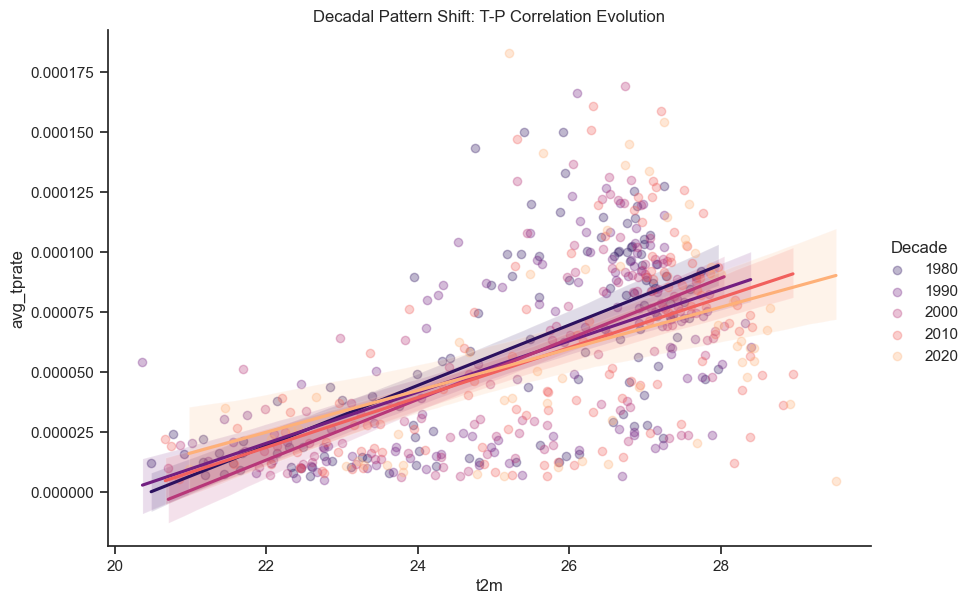

In [10]:
sns.lmplot(data=df_final, x=name_t2m, y=name_tp, hue='Decade', 
           palette='magma', scatter_kws={'alpha':0.3}, height=6, aspect=1.5)
plt.title("Decadal Pattern Shift: T-P Correlation Evolution")
plt.show()

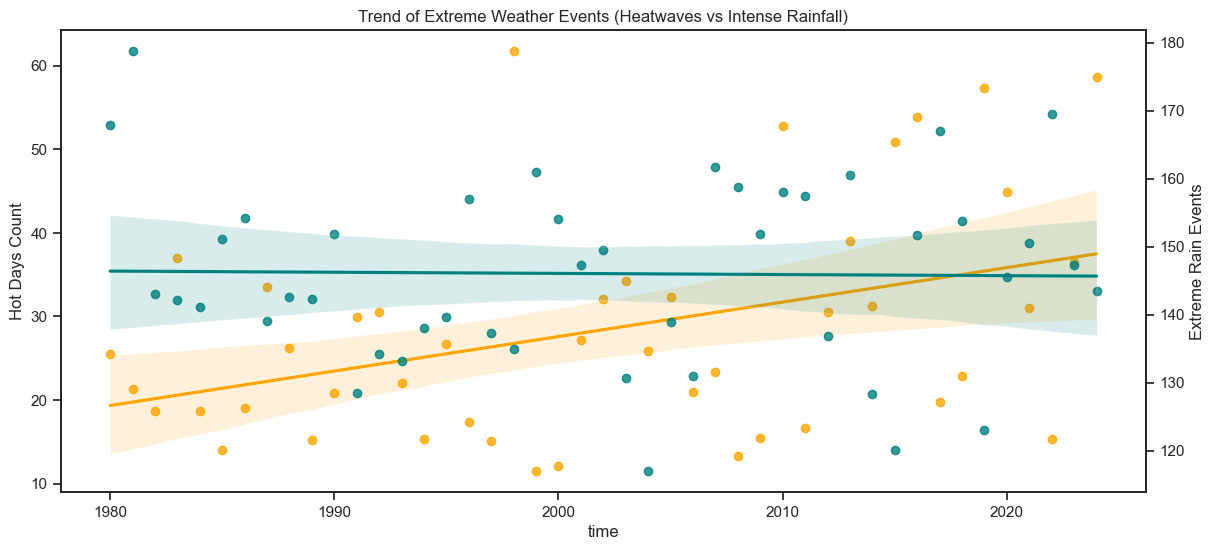

In [11]:
hot_days = (raw_t2m > 35).resample(time='1YS').sum(dim='time').mean(dim=['latitude', 'longitude']).to_dataframe(name='hot_days')
heavy_rain = (raw_tp > raw_tp.quantile(0.95)).resample(time='1YS').sum(dim='time').mean(dim=['latitude', 'longitude']).to_dataframe(name='extreme_rain')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.regplot(x=hot_days.index.year, y=hot_days['hot_days'], ax=ax1, color='orange', label='Hot Days (>35°C)')
sns.regplot(x=heavy_rain.index.year, y=heavy_rain['extreme_rain'], ax=ax2, color='teal', label='Heavy Rain Days')

ax1.set_ylabel("Hot Days Count")
ax2.set_ylabel("Extreme Rain Events")
plt.title("Trend of Extreme Weather Events (Heatwaves vs Intense Rainfall)")
plt.show()

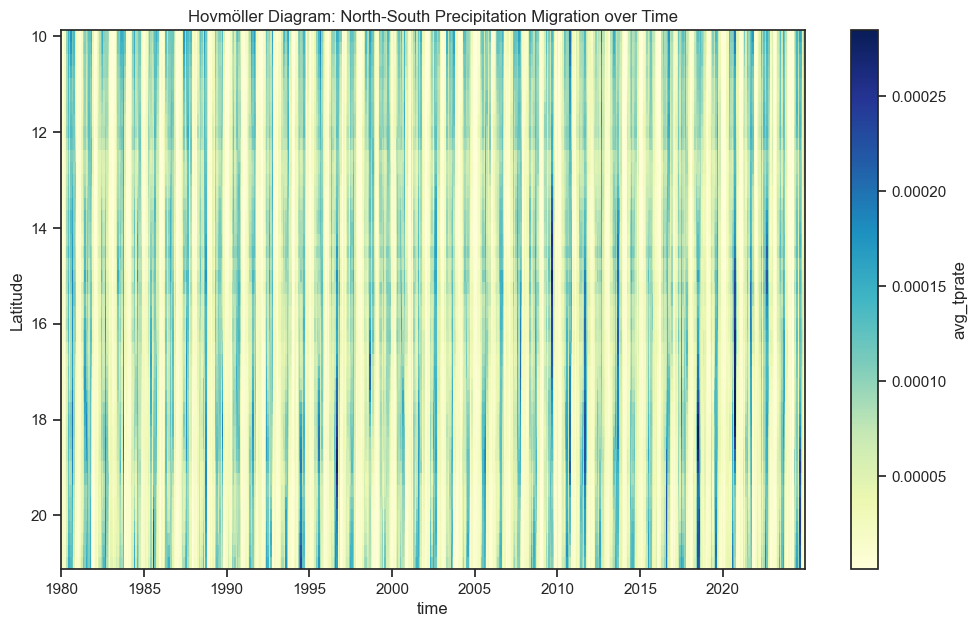

In [12]:
hov = raw_tp.resample(time='1MS').mean().mean(dim='longitude')
plt.figure(figsize=(12, 7))
hov.T.plot(cmap='YlGnBu', yincrease=False)
plt.title("Hovmöller Diagram: North-South Precipitation Migration over Time")
plt.ylabel("Latitude")
plt.show()

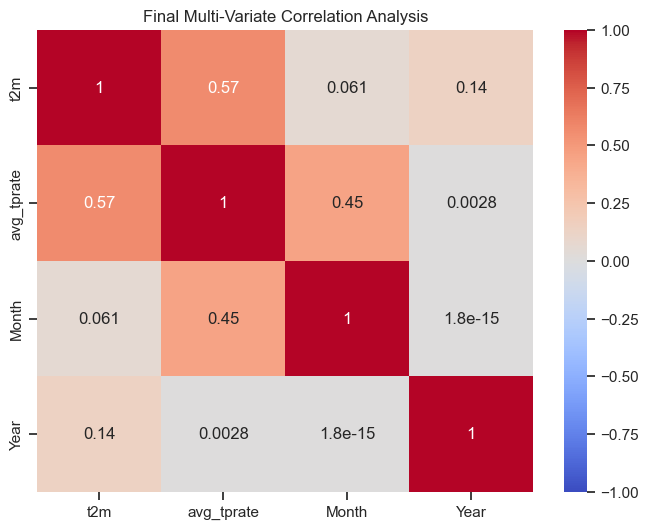

In [13]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_final[[name_t2m, name_tp, 'Month', 'Year']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Final Multi-Variate Correlation Analysis")
plt.show()
